# Diabetes Dataset Analysis and Preprocessing (Pima Indians)

**Objective:** Load, explore, clean, normalize, and visualize the diabetes dataset (Pima Indians Diabetes Database), in order to understand the impact of preprocessing on biomedical data.

The dataset contains 768 patient records with the following columns:

- `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, `Outcome` (1 = diabetes, 0 = no diabetes)


## Part 1: Data Loading and Exploration

### 1.1 Import libraries and load the dataset with Pandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# We load the dataset directly from a public GitHub repository
# (equivalent to the original "Pima Indians Diabetes Database")
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)


Dataset shape: (768, 9)


### 1.2 Display the first few rows of the dataset

In [ ]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 1.3 Identify null or inconsistent values

This dataset has no explicit `NaN` values, but several columns use **0** as an "inconsistent" or physiologically
impossible value (for example, a person cannot have Glucose, Blood Pressure, or BMI equal to 0). Let's check both cases.


In [ ]:
# 1) Check for explicit null (NaN) values
print("Null values per column:")
print(df.isnull().sum())


Null values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# 2) Check for "inconsistent" zeros in columns where 0 makes no clinical sense
cols_with_possible_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Number of 0 values per column (possible missing data):\n")
for col in cols_with_possible_invalid_zeros:
    zero_count = (df[col] == 0).sum()
    percentage = zero_count / len(df) * 100
    print(f"{col:20s}: {zero_count:4d} zeros  ({percentage:5.2f}% of total)")


Number of 0 values per column (possible missing data):

Glucose             :    5 zeros  ( 0.65% of total)
BloodPressure       :   35 zeros  ( 4.56% of total)
SkinThickness       :  227 zeros  (29.56% of total)
Insulin             :  374 zeros  (48.70% of total)
BMI                 :   11 zeros  ( 1.43% of total)


### 1.4 Descriptive statistics

In [ ]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Part 2: Data Cleaning and Normalization

### 2.1 Replace zero values with the median of each column

We replace the "inconsistent" zeros (Glucose, BloodPressure, SkinThickness, Insulin, BMI) with the **median** of each
column, since the median is more robust to outliers than the mean.


In [ ]:
df_clean = df.copy()

for col in cols_with_possible_invalid_zeros:
    median = df_clean[df_clean[col] != 0][col].median()  # median computed ONLY from valid (!= 0) values
    df_clean[col] = df_clean[col].replace(0, median)

# Verify that no zeros remain in those columns
print("Number of zeros after cleaning:\n")
for col in cols_with_possible_invalid_zeros:
    print(f"{col:20s}: {(df_clean[col] == 0).sum()} zeros")

df_clean.head()


Number of zeros after cleaning:

Glucose             : 0 zeros
BloodPressure       : 0 zeros
SkinThickness       : 0 zeros
Insulin             : 0 zeros
BMI                 : 0 zeros


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2.2 Min-Max Scaling normalization

We scale all numerical columns (except `Outcome`, which is the target/categorical variable) to the [0, 1] range
using scikit-learn's `MinMaxScaler`.


In [ ]:
numeric_columns = df_clean.columns.drop("Outcome")

scaler = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[numeric_columns] = scaler.fit_transform(df_clean[numeric_columns])

df_normalized.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333,1
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667,0
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333,1
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1


In [ ]:
# Quick check: all numerical columns should now be between 0 and 1
df_normalized[numeric_columns].describe().loc[["min", "max"]]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Part 3: Data Visualization

### 3.1 Histogram of Glucose levels: before and after normalization

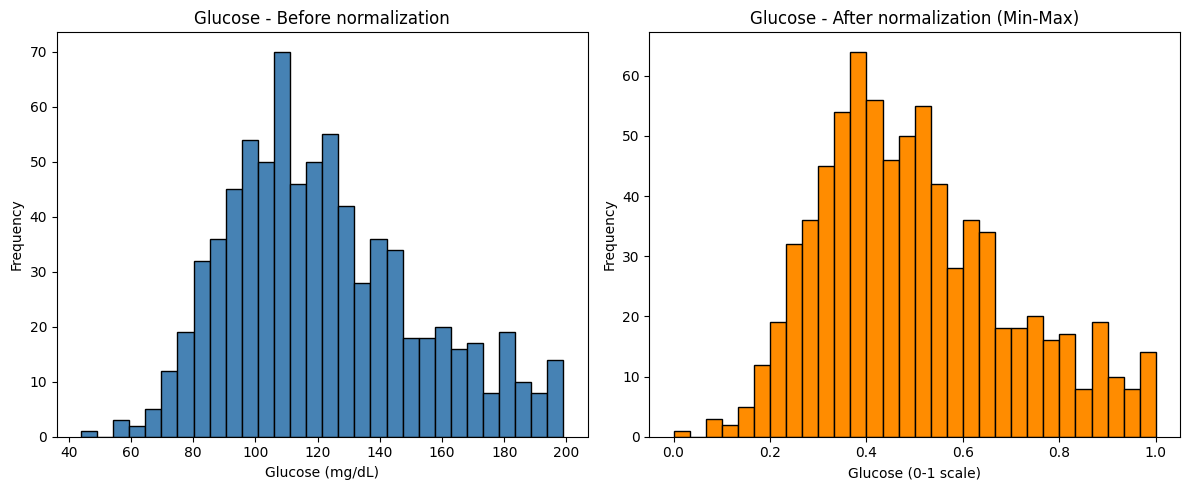

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_clean["Glucose"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Glucose - Before normalization")
axes[0].set_xlabel("Glucose (mg/dL)")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_normalized["Glucose"], bins=30, color="darkorange", edgecolor="black")
axes[1].set_title("Glucose - After normalization (Min-Max)")
axes[1].set_xlabel("Glucose (0-1 scale)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### 3.2 Boxplot to identify outliers in Blood Pressure

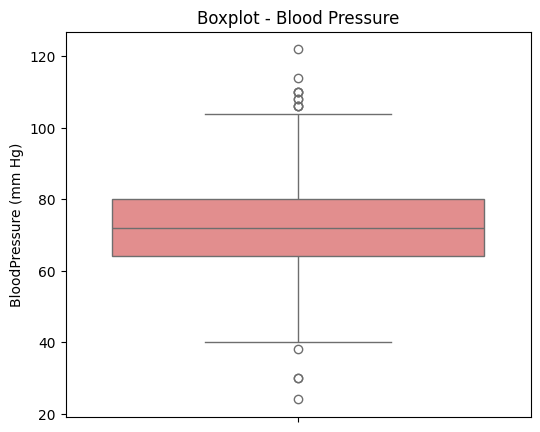

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_clean["BloodPressure"], color="lightcoral")
plt.title("Boxplot - Blood Pressure")
plt.ylabel("BloodPressure (mm Hg)")
plt.show()


### 3.3 Scatter plot: Glucose vs BMI

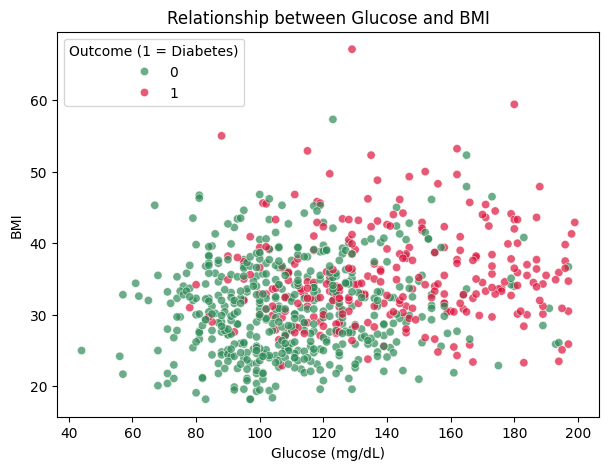

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clean, x="Glucose", y="BMI", hue="Outcome", palette=["seagreen", "crimson"], alpha=0.7)
plt.title("Relationship between Glucose and BMI")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI")
plt.legend(title="Outcome (1 = Diabetes)")
plt.show()


### 3.4 Bar chart: patients with and without diabetes (Outcome)

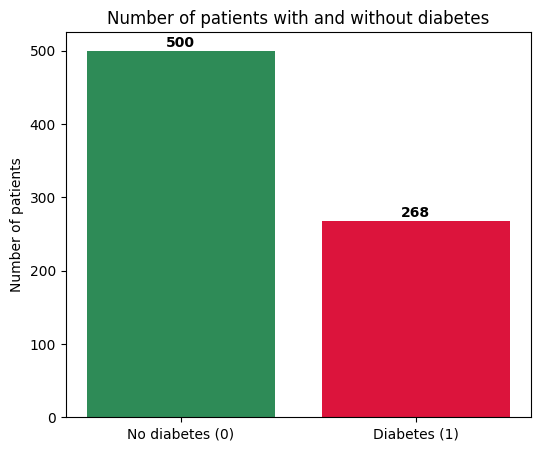

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
outcome_counts = df_clean["Outcome"].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(["No diabetes (0)", "Diabetes (1)"], outcome_counts.values, color=["seagreen", "crimson"])
plt.title("Number of patients with and without diabetes")
plt.ylabel("Number of patients")

for i, value in enumerate(outcome_counts.values):
    plt.text(i, value + 5, str(value), ha="center", fontweight="bold")

plt.show()

print(outcome_counts)


## Part 4: Analysis Questions

**1. What impact do missing values have on data analysis?**

Missing values (or zeros "disguised" as missing data, as in this dataset) can bias descriptive statistics (mean,
standard deviation), reduce the statistical power of the analysis, and lead to incorrect conclusions if not detected.
In Machine Learning models, they can cause training errors or make the model learn false patterns (for example,
treating "Glucose = 0" as a real value instead of a missing one).

**2. How can we detect and handle outliers in biomedical datasets?**

Outliers can be detected using statistical methods such as the **interquartile range (IQR)**, **z-score**, or
visually with **boxplots** and **histograms**. In the biomedical field it's also essential to apply **clinical
knowledge** (for example, knowing that a blood pressure of 0 or an age of 200 years is impossible). To handle them,
you can remove the records, cap (winsorize) the extreme values, or impute them with the median/mode, depending on
whether the outlier is a measurement error or a real clinical variation that should be kept.

**3. What are some common causes of missing or incorrect data in biomedical studies?**

Errors in manual data entry, malfunctioning or uncalibrated measurement equipment, patients who don't complete all
tests, values marked as "not applicable" that get recorded as 0 (as in this dataset), transcription errors between
systems, and variability between different observers or measurement devices.

**4. How does normalizing data improve the performance of Machine Learning models?**

Many algorithms (such as KNN, SVM, gradient-descent-based logistic regression, and neural networks) are sensitive to
the scale of the variables. If one variable has a much larger range than another (for example, Insulin vs. BMI), it
can dominate distance or gradient calculations. Normalizing (e.g., with Min-Max Scaling) puts all variables on a
comparable scale, which speeds up training convergence and prevents some variables from "outweighing" others simply
because of their numeric scale, rather than their actual relevance.

**5. Why is visualizing data an important step before applying Machine Learning models?**

Visualization allows you to quickly detect outliers, missing values, skewed distributions, relationships between
variables (correlations), and class imbalance (as seen in the `Outcome` bar chart). This information guides key
preprocessing decisions and model selection, and helps anticipate problems before investing time in training a model
with poorly prepared data.

**6. Why is preprocessing critical when working with medical datasets?**

Because decisions based on these models can directly affect a patient's health and treatment. Poorly preprocessed
data (with invalid zeros, untreated outliers, or inconsistent scales) can lead to unreliable models, with false
positives or false negatives that have serious consequences in a clinical context (for example, failing to detect an
actual case of diabetes).

**7. What ethical concerns should be considered when handling patient data?**

Confidentiality and anonymization of the data must be ensured, privacy regulations must be followed (such as HIPAA or
local data protection laws), informed consent must be obtained for the use of the information, biases in the data
that could discriminate against certain population groups must be avoided, and there should be transparency about how
the model's results will be used, especially when they influence diagnosis or treatment decisions.
